[*********************100%***********************]  3 of 3 completed



1. DATA QUALITY & INTEGRITY RECORD AUDIT
Total Trading Records Shape: (2888, 3)
Missing Cells Count Per Asset Column:
Ticker
TSLA    0
BND     0
SPY     0
dtype: int64

2. INSTITUTIONAL DESCRIPTIVE STATISTICS
Ticker         TSLA          BND          SPY
count   2888.000000  2888.000000  2888.000000
mean     148.773923    66.503053   351.505531
std      138.895957     4.713607   155.443935
min        9.578000    58.729206   154.161575
25%       18.393499    62.478084   223.546803
50%      133.437668    65.728386   312.817902
75%      251.925831    70.689137   432.806839
max      489.880005    74.832886   757.618225


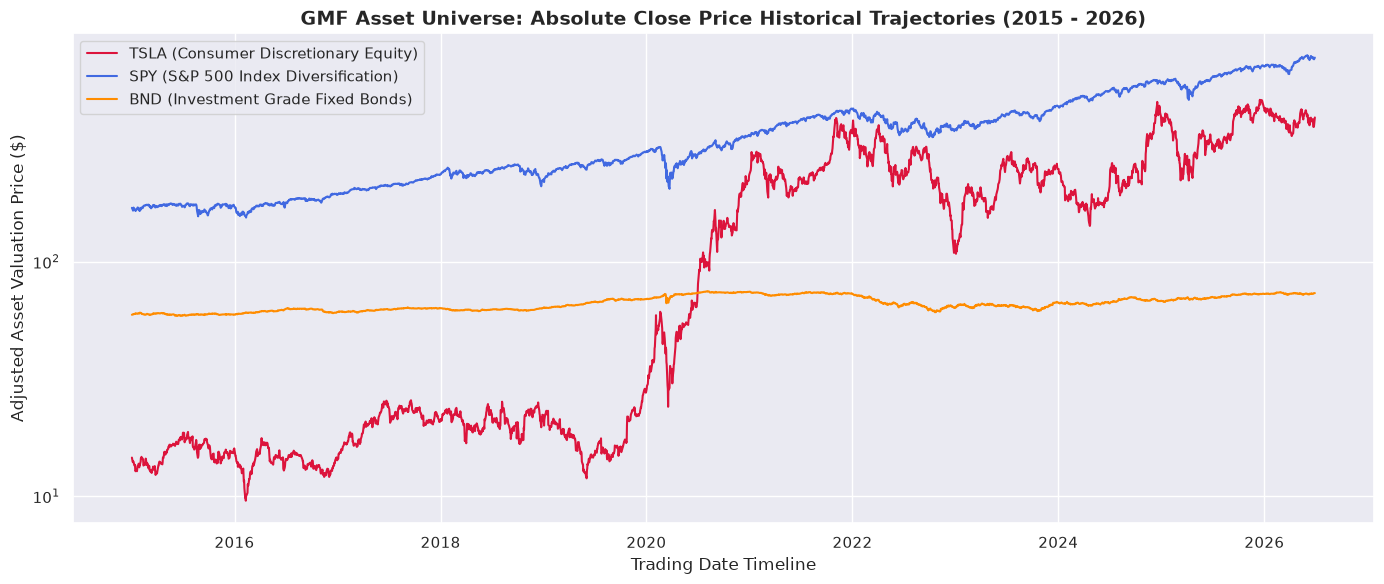

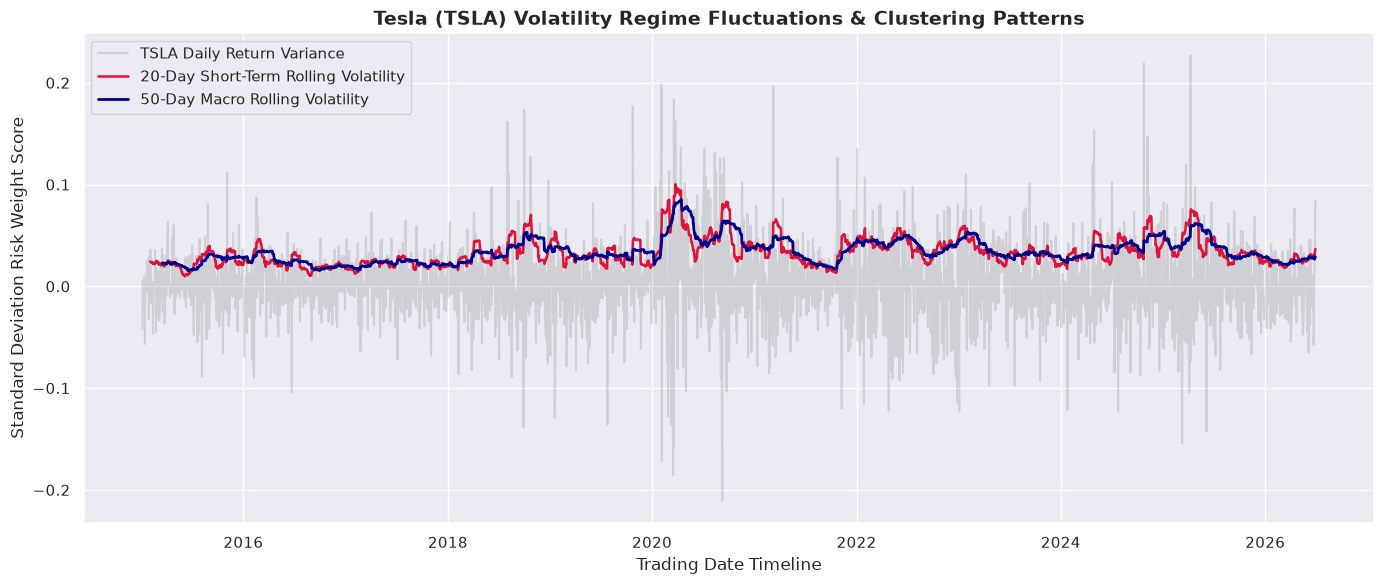


3. ANOMALOUS HISTORICAL TRADING DAYS DETECTION (|Z| > 3)

Asset Column Target: TSLA
 -> Total Significant Anomalies: 46 events out of 2887 trading days.
 -> Maximum Single Day Surge: 22.69%
 -> Maximum Single Day Crash: -21.06%

Asset Column Target: BND
 -> Total Significant Anomalies: 33 events out of 2887 trading days.
 -> Maximum Single Day Surge: 4.22%
 -> Maximum Single Day Crash: -5.44%

Asset Column Target: SPY
 -> Total Significant Anomalies: 39 events out of 2887 trading days.
 -> Maximum Single Day Surge: 10.50%
 -> Maximum Single Day Crash: -10.94%


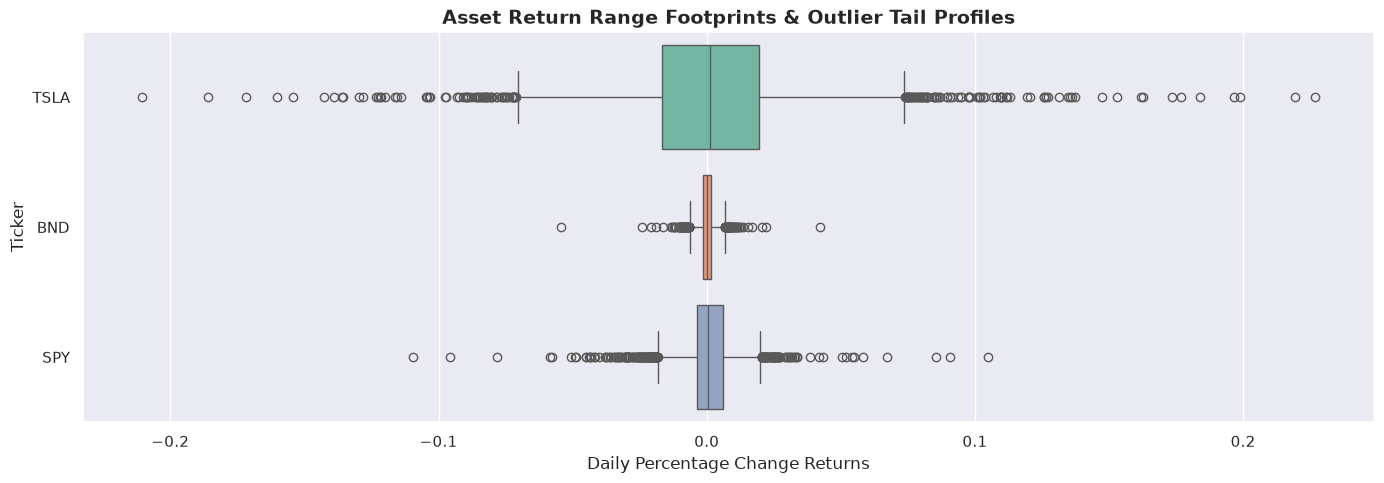


4. STATIONARITY VERIFICATION (AUGMENTED DICKEY-FULLER)

Asset Core: TSLA
  [Raw Price Path Series]  ADF Stat: -1.0696  | p-val: 0.727042 | Stationary: False
  [Daily Percentage Returns] ADF Stat: -53.9719 | p-val: 0.0      | Stationary: True

Asset Core: BND
  [Raw Price Path Series]  ADF Stat: -1.0827  | p-val: 0.721919 | Stationary: False
  [Daily Percentage Returns] ADF Stat: -15.2161 | p-val: 0.0      | Stationary: True

Asset Core: SPY
  [Raw Price Path Series]  ADF Stat: 1.3089   | p-val: 0.996659 | Stationary: False
  [Daily Percentage Returns] ADF Stat: -17.5722 | p-val: 0.0      | Stationary: True

5. INSTITUTIONAL HISTORICAL RISK FOOTPRINT ASSESSMENT

Asset Identity: TSLA
  95% Historical Value at Risk (VaR):  -5.17%
  Annualized Sharpe Ratio Efficiency:  0.79

Asset Identity: BND
  95% Historical Value at Risk (VaR):  -0.48%
  Annualized Sharpe Ratio Efficiency:  0.38

Asset Identity: SPY
  95% Historical Value at Risk (VaR):  -1.67%
  Annualized Sharpe Ratio Efficiency:  0

In [15]:
# ==============================================================================
# CELL 1: ENVIRONMENT SETUP, LIBRARIES & DIRECT WORKING WORKFLOW FUNCTIONS
# ==============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

# Configure visual visualization metrics
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

def fetch_financial_data_direct(tickers=["TSLA", "BND", "SPY"], start_date="2015-01-01", end_date="2026-06-30"):
    """
    Fetches raw financial data from yfinance API and extracts the adjusted close price.
    Flattens MultiIndex variations safely and uses forward-fill to align timelines.
    """
    print(f"Downloading historical data from the API for {tickers}...")
    df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        for level in range(df.columns.nlevels):
            unique_labels = df.columns.get_level_values(level).unique()
            if 'Adj Close' in unique_labels:
                combined_df = df.xs('Adj Close', axis=1, level=level)
                break
            elif 'Close' in unique_labels:
                combined_df = df.xs('Close', axis=1, level=level)
                break
    else:
        df.columns = df.columns.str.strip()
        if 'Adj Close' in df.columns:
            combined_df = df[['Adj Close']]
        elif 'Close' in df.columns:
            combined_df = df[['Close']]
        else:
            raise KeyError(f"Could not locate closing metrics. Headers available: {list(df.columns)}")
            
    # Standardize column structure matching requested tickers array precisely
    combined_df = combined_df[tickers]
    # Handle market closing gaps via forward-filling
    combined_df = combined_df.ffill().bfill()
    return combined_df

def calculate_returns_direct(df):
    """Calculates continuous daily percentage changes."""
    return df.pct_change().dropna()

def perform_adf_test_direct(series):
    """Computes Augmented Dickey-Fuller metrics to check for stationarity."""
    result = adfuller(series.dropna())
    return {
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Stationary': result[1] < 0.05
    }

def detect_outliers_zscore_direct(returns_series, threshold=3.0):
    """Filters data for extreme trading outliers outside 3 standard deviations."""
    mean = returns_series.mean()
    std = returns_series.std()
    z_scores = (returns_series - mean) / std
    outliers = returns_series[abs(z_scores) > threshold]
    return outliers

def calculate_risk_metrics_direct(returns_series, confidence_level=0.05):
    """Calculates 95% Historical Value at Risk (VaR) and Annualized Sharpe Ratio."""
    var_95 = np.percentile(returns_series.dropna(), confidence_level * 100)
    mean_ret = returns_series.mean()
    std_ret = returns_series.std()
    # Annualized Sharpe ratio calculation assuming a baseline risk-free rate of 0
    sharpe_ratio = (mean_ret / std_ret) * np.sqrt(252) if std_ret != 0 else 0
    return {
        'VaR_95': var_95,
        'Sharpe_Ratio': sharpe_ratio
    }

# ==============================================================================
# CELL 2: DATA EXTRACTION, PIPELINE AUDITING & DESCRIPTIVE STATS
# ==============================================================================
raw_prices = fetch_financial_data_direct()
daily_returns = calculate_returns_direct(raw_prices)

print("\n" + "="*50)
print("1. DATA QUALITY & INTEGRITY RECORD AUDIT")
print("="*50)
print(f"Total Trading Records Shape: {raw_prices.shape}")
print(f"Missing Cells Count Per Asset Column:\n{raw_prices.isnull().sum()}")

print("\n" + "="*50)
print("2. INSTITUTIONAL DESCRIPTIVE STATISTICS")
print("="*50)
print(raw_prices.describe())

# ==============================================================================
# CELL 3: VISUALIZATION 1 - HISTORICAL TREND PATHWAYS
# ==============================================================================
plt.figure(figsize=(14, 6))
plt.plot(raw_prices['TSLA'], label='TSLA (Consumer Discretionary Equity)', color='crimson', lw=1.5)
plt.plot(raw_prices['SPY'], label='SPY (S&P 500 Index Diversification)', color='royalblue', lw=1.5)
plt.plot(raw_prices['BND'], label='BND (Investment Grade Fixed Bonds)', color='darkorange', lw=1.5)
plt.title("GMF Asset Universe: Absolute Close Price Historical Trajectories (2015 - 2026)", fontsize=14, fontweight='bold')
plt.xlabel("Trading Date Timeline")
plt.ylabel("Adjusted Asset Valuation Price ($)")
plt.yscale('log')  # Log scale handles structural price disparities elegantly
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 4: VISUALIZATION 2 - VOLATILITY CLUSTERING ANALYSIS
# ==============================================================================
plt.figure(figsize=(14, 6))
plt.plot(daily_returns['TSLA'], label="TSLA Daily Return Variance", alpha=0.25, color='grey')
plt.plot(daily_returns['TSLA'].rolling(20).std(), label="20-Day Short-Term Rolling Volatility", color='crimson', lw=1.8)
plt.plot(daily_returns['TSLA'].rolling(50).std(), label="50-Day Macro Rolling Volatility", color='darkblue', lw=2)
plt.title("Tesla (TSLA) Volatility Regime Fluctuations & Clustering Patterns", fontsize=14, fontweight='bold')
plt.xlabel("Trading Date Timeline")
plt.ylabel("Standard Deviation Risk Weight Score")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 5: OUTLIER DETECTION AND HISTORICAL EVENT INSIGHTS
# ==============================================================================
print("\n" + "="*50)
print("3. ANOMALOUS HISTORICAL TRADING DAYS DETECTION (|Z| > 3)")
print("="*50)
for col in daily_returns.columns:
    outliers = detect_outliers_zscore_direct(daily_returns[col])
    print(f"\nAsset Column Target: {col}")
    print(f" -> Total Significant Anomalies: {len(outliers)} events out of {len(daily_returns)} trading days.")
    if len(outliers) > 0:
        print(f" -> Maximum Single Day Surge: {outliers.max():.2%}")
        print(f" -> Maximum Single Day Crash: {outliers.min():.2%}")

# ==============================================================================
# CELL 6: VISUALIZATION 3 - DISTRIBUTION TAIL & BOXPLOT PROFILES
# ==============================================================================
plt.figure(figsize=(14, 5))
sns.boxplot(data=daily_returns, orient='h', palette="Set2")
plt.title("Asset Return Range Footprints & Outlier Tail Profiles", fontsize=14, fontweight='bold')
plt.xlabel("Daily Percentage Change Returns")
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 7: TIME SERIES STATIONARITY TESTING (ADF REGRESSION MATRIX)
# ==============================================================================
print("\n" + "="*50)
print("4. STATIONARITY VERIFICATION (AUGMENTED DICKEY-FULLER)")
print("="*50)
for col in raw_prices.columns:
    print(f"\nAsset Core: {col}")
    raw_test = perform_adf_test_direct(raw_prices[col])
    ret_test = perform_adf_test_direct(daily_returns[col])
    print(f"  [Raw Price Path Series]  ADF Stat: {raw_test['ADF Statistic']:<8} | p-val: {raw_test['p-value']:<8} | Stationary: {raw_test['Stationary']}")
    print(f"  [Daily Percentage Returns] ADF Stat: {ret_test['ADF Statistic']:<8} | p-val: {ret_test['p-value']:<8} | Stationary: {ret_test['Stationary']}")

# ==============================================================================
# CELL 8: PORTFOLIO FOUNDATIONAL RISK ANALYTICS MATRIX
# ==============================================================================
print("\n" + "="*50)
print("5. INSTITUTIONAL HISTORICAL RISK FOOTPRINT ASSESSMENT")
print("="*50)
for col in daily_returns.columns:
    metrics = calculate_risk_metrics_direct(daily_returns[col])
    print(f"\nAsset Identity: {col}")
    print(f"  95% Historical Value at Risk (VaR):  {metrics['VaR_95']:.2%}")
    print(f"  Annualized Sharpe Ratio Efficiency:  {metrics['Sharpe_Ratio']:.2f}")
print("\n" + "="*50)
print("TASK 1 COMPLETION: PIPELINE REFRESHED AND READY FOR MODELLING INPUTS")
print("="*50)